In [1]:
import numpy as np
import plotly.graph_objects as go
import math
import plotly.io as pio
pio.renderers.default = "png"

# Example 7.1 : $n$-step TD Methods on the Random Walk

In [2]:
def sampleVRWTrajectory(policy, nStates=5, leftReward=0):
    currentState = nStates // 2
    stateTrajectory = []
    actionTrajectory = []
    rewardTrajectory = []

    terminal = False
    while not terminal:
        stateTrajectory.append(currentState)
        reward = 0
        currentAction = np.random.choice([-1, 1], p=policy[currentState])
        actionTrajectory.append(currentAction)
        if currentState == nStates - 1 and currentAction == 1:
            terminal = True
            reward = 1
        elif currentState == 0 and currentAction == -1:
            terminal = True
            reward = leftReward
        rewardTrajectory.append(reward)
        currentState += currentAction

    trajectory = np.empty((len(stateTrajectory), 3), dtype=int)
    trajectory[:, 0] = stateTrajectory
    trajectory[:, 1] = actionTrajectory
    trajectory[:, 2] = rewardTrajectory

    return trajectory    

In [3]:
def nStepTDVRW(episodes, vInit, nStates=5, alpha=0.1, n=2, leftReward=0):
    V = vInit.copy()
    maxEpisodes = len(episodes)
    learningCurve = np.empty((maxEpisodes, nStates))
    for episode, trajectory in enumerate(episodes):
        T = len(trajectory)
        for tau in range(T):
            gain = np.sum(trajectory[tau : tau + n, 2])
            if tau + n < len(trajectory):
                gain += V[trajectory[tau + n, 0]]
            V[trajectory[tau, 0]] += alpha * (gain - V[trajectory[tau, 0]])

        learningCurve[episode] = V.copy()
        episode += 1

    trueValue = np.arange(1, nStates + 1) / (nStates + 1) + leftReward * (1 - np.arange(1, nStates + 1) / (nStates + 1))
    error = np.mean(np.sqrt(np.mean((learningCurve - trueValue) ** 2, axis=1)))
    return error

In [4]:
def prepareExperiments(vInit, policy, nStates, leftReward, nEpisodes, nReps, nList, alphas):
    trajectories = []
    for rep in range(nReps):
        repTrajectories = []
        for episode in range(nEpisodes):
            repTrajectories.append(sampleVRWTrajectory(policy, nStates=nStates, leftReward=leftReward))
        trajectories.append(repTrajectories)

    errors = {}
    for n in nList:
        nErrors = []
        for alpha in alphas:
            nAlphaErrors = []
            for rep in range(nReps):
                nAlphaErrors.append(nStepTDVRW(trajectories[rep], vInit, nStates=nStates, alpha=alpha, n=n, leftReward=leftReward))
            nErrors.append(np.mean(nAlphaErrors))
        errors[n] = nErrors

    return errors

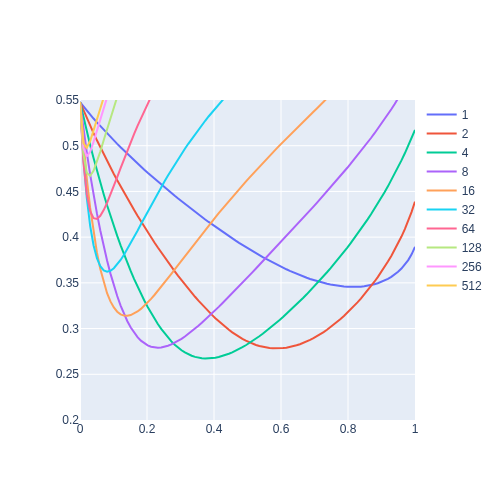

In [5]:
nStates = 19
leftReward = -1
nEpisodes = 10
nReps = 100
nList = 2 ** np.arange(10)
alphas = np.linspace(0, 1, 100)
vInitVRW = np.zeros(nStates)
policy = 0.5 * np.ones((nStates, 2))
nCurves = prepareExperiments(vInitVRW, policy, nStates, leftReward, nEpisodes, nReps, nList, alphas)
fig = go.Figure()
for n in nList:
    fig.add_trace(go.Scatter(x=alphas, y=nCurves[n], name=str(n)))
fig.update_layout(width=500)
fig.update_yaxes(range=[0.2, 0.55])
fig.show()

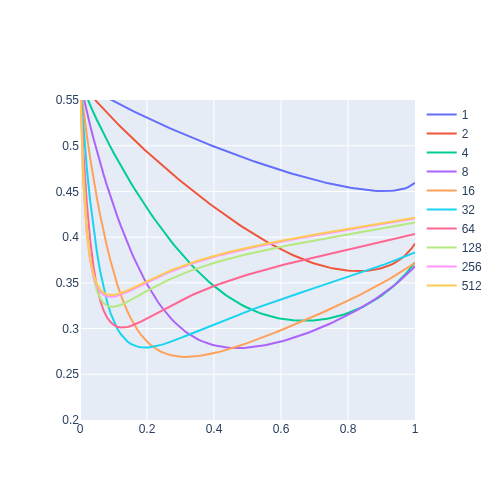

In [6]:
nStates = 19
leftReward = 0
nEpisodes = 10
nReps = 100
nList = 2 ** np.arange(10)
alphas = np.linspace(0, 1, 100)
vInitVRW = np.zeros(nStates)
policy = 0.5 * np.ones((nStates, 2))
nCurves = prepareExperiments(vInitVRW, policy, nStates, leftReward, nEpisodes, nReps, nList, alphas)
fig = go.Figure()
for n in nList:
    fig.add_trace(go.Scatter(x=alphas, y=nCurves[n], name=str(n)))
fig.update_layout(width=500)
fig.update_yaxes(range=[0.2, 0.55])
fig.show()


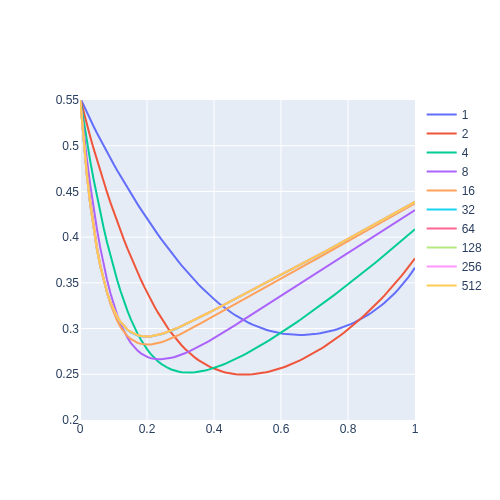

In [7]:
nStates = 5
leftReward = 0
nEpisodes = 10
nReps = 100
nList = 2 ** np.arange(10)
alphas = np.linspace(0, 1, 100)
vInitVRW = np.zeros(nStates)
policy = 0.5 * np.ones((nStates, 2))
nCurves = prepareExperiments(vInitVRW, policy, nStates, leftReward, nEpisodes, nReps, nList, alphas)
fig = go.Figure()
for n in nList:
    fig.add_trace(go.Scatter(x=alphas, y=nCurves[n], name=str(n)))
fig.update_layout(width=500)
fig.update_yaxes(range=[0.2, 0.55])
fig.show()

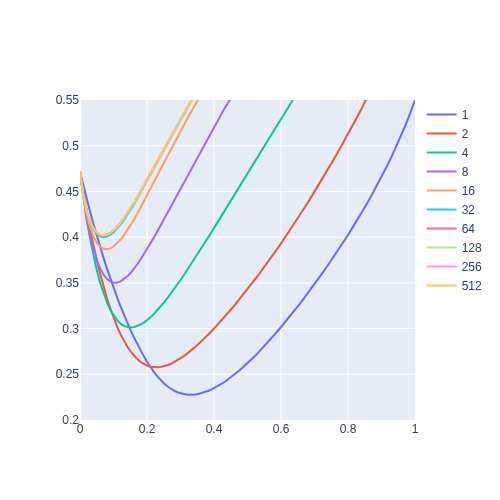

In [8]:
nStates = 5
leftReward = -1
nEpisodes = 10
nReps = 100
nList = 2 ** np.arange(10)
alphas = np.linspace(0, 1, 100)
vInitVRW = np.zeros(nStates)
policy = 0.5 * np.ones((nStates, 2))
nCurves = prepareExperiments(vInitVRW, policy, nStates, leftReward, nEpisodes, nReps, nList, alphas)
fig = go.Figure()
for n in nList:
    fig.add_trace(go.Scatter(x=alphas, y=nCurves[n], name=str(n)))
fig.update_layout(width=500)
fig.update_yaxes(range=[0.2, 0.55])
fig.show()

# Exercise 7.5

Input: an arbitrary behaviour policy $b$ such that $b(a|s)>0$, for all $s\in \mathcal{S}, a \in \mathcal{A}$<br>
Parameters: step size $\alpha \in (0, 1]$, a positive ineger $n$  
Initialize $V(s)$ arbitrarily, for all $s \in \mathcal{S}^+$, except that $V$(terminal)$=0$  
Loop for each episode:  
&nbsp;&nbsp;&nbsp;&nbsp;Initialize and store $S_0 \neq$ terminal  
&nbsp;&nbsp;&nbsp;&nbsp;$T \gets \infty$  
&nbsp;&nbsp;&nbsp;&nbsp;Loop for $t=0, 1, 2, \cdots$:  
&nbsp;&nbsp;&nbsp;&nbsp;|&nbsp;&nbsp;&nbsp;&nbsp;If $t<T$, then:  
&nbsp;&nbsp;&nbsp;&nbsp;|&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;Take action $A_t$ according to $b(.|S_t)$ and store it  
&nbsp;&nbsp;&nbsp;&nbsp;|&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;Observe and store the next reward $R_{t+1}$ and the next state $S_{t+1}$  
&nbsp;&nbsp;&nbsp;&nbsp;|&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;If $S_{t+1}$ is terminal, then $T \gets t + 1$  
&nbsp;&nbsp;&nbsp;&nbsp;|&nbsp;&nbsp;&nbsp;&nbsp;$\tau \gets t -n + 1$ ($\tau$ is the time whose state's estimate is being updated)  
&nbsp;&nbsp;&nbsp;&nbsp;|&nbsp;&nbsp;&nbsp;&nbsp;If $\tau \geq 0$:  
&nbsp;&nbsp;&nbsp;&nbsp;|&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;$h \gets \min(\tau + n, T)$  
&nbsp;&nbsp;&nbsp;&nbsp;|&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;$G \gets V(S_h)$  
&nbsp;&nbsp;&nbsp;&nbsp;|&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;Loop for $k=h-1, h-2, \cdots, \tau$:   
&nbsp;&nbsp;&nbsp;&nbsp;|&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;$\rho \gets \frac{\pi(A_k|S_k)}{b(A_k|S_k)}$  
&nbsp;&nbsp;&nbsp;&nbsp;|&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;$G \gets \rho (R_{k+1} + \gamma G) + (1 - \rho) V(S_k)$  
&nbsp;&nbsp;&nbsp;&nbsp;|&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;$V(S_{\tau}) \gets V(S_{\tau}) + \alpha (G - V(S_{\tau}))$  
&nbsp;&nbsp;&nbsp;&nbsp;Until $\tau = T - 1$

# Exercise 7.6

\begin{align}
    \mathbb{E}_b\left[\bar{V}_{h-1}(S_{t+1}) - \rho_{t+1}Q_{h-1}(S_{t+1}, A_{t+1}) |S_t, A_t\right] &= \mathbb{E}_b\left[\sum_a \pi(a|S_{t+1})Q_{h-1}(S_{t+1}, a) - \frac{\pi(A_{t+1}|S_{t+1})}{b(A_{t+1}|S_{t+1})}Q_{h-1}(S_{t+1}, A_{t+1}) |S_t, A_t\right] \\
    &= \sum_{s_{t+1}}\sum_{a'} p(s_{t+1}|S_t, A_t) b(a'|s_{t+1}) \left(\sum_a \pi(a|s_{t+1})Q_{h-1}(s_{t+1}, a) \right. \\
    & \left .-
    \frac{\pi(a'|s_{t+1})}{b(a'|s_{t+1})}Q_{h-1}(s_{t+1}, a')\right) \\
    &= \sum_{s_{t+1}} p(s_{t+1}|S_t, A_t) \left (\sum_a \pi(a|s_{t+1})Q_{h-1}(s_{t+1}, a) - \sum_{a'} \pi(a'|s_{t+1}) Q_{h-1}(s_{t+1}, a') \right) \\
    &= 0
\end{align}

# Exercise 7.7

Input: an arbitrary behaviour policy $b$ such that $b(a|s)>0$, for all $s\in \mathcal{S}, a \in \mathcal{A}$<br>
Parameters: step size $\alpha \in (0, 1]$, a positive ineger $n$  
Initialize $Q(s, a)$ arbitrarily, for all $s \in \mathcal{S}^+$, for all $a \in \mathcal{A}$, except that $Q(terminal, .)=0$  
Loop for each episode:  
&nbsp;&nbsp;&nbsp;&nbsp;Initialize and store $S_0 \neq$ terminal  
&nbsp;&nbsp;&nbsp;&nbsp;$T \gets \infty$  
&nbsp;&nbsp;&nbsp;&nbsp;Loop for $t=0, 1, 2, \cdots$:  
&nbsp;&nbsp;&nbsp;&nbsp;|&nbsp;&nbsp;&nbsp;&nbsp;If $t<T$, then:  
&nbsp;&nbsp;&nbsp;&nbsp;|&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;Take action $A_t \sim b(.|S_t)$ and store it  
&nbsp;&nbsp;&nbsp;&nbsp;|&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;Observe and store the next reward $R_{t+1}$ and the next state $S_{t+1}$  
&nbsp;&nbsp;&nbsp;&nbsp;|&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;If $S_{t+1}$ is terminal:  
&nbsp;&nbsp;&nbsp;&nbsp;|&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;$T \gets t + 1$  
&nbsp;&nbsp;&nbsp;&nbsp;|&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;else:  
&nbsp;&nbsp;&nbsp;&nbsp;|&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;Select and store $A_{t+1} \sim b(.|S_{t+1})$  
&nbsp;&nbsp;&nbsp;&nbsp;|&nbsp;&nbsp;&nbsp;&nbsp;$\tau \gets t - n + 1$ ($\tau$ is the time whose state's estimate is being updated)  
&nbsp;&nbsp;&nbsp;&nbsp;|&nbsp;&nbsp;&nbsp;&nbsp;If $\tau \geq 0$:  
&nbsp;&nbsp;&nbsp;&nbsp;|&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;$h \gets \tau + n$  
&nbsp;&nbsp;&nbsp;&nbsp;|&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;if $h < T$:  
&nbsp;&nbsp;&nbsp;&nbsp;|&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp; $G \gets Q(S_h, A_h)$  
&nbsp;&nbsp;&nbsp;&nbsp;|&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;else:  
&nbsp;&nbsp;&nbsp;&nbsp;|&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp; $h \gets T - 1$  
&nbsp;&nbsp;&nbsp;&nbsp;|&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp; $G \gets R_T$  
&nbsp;&nbsp;&nbsp;&nbsp;|&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;Loop for $k=h-1, h-2, \cdots, \tau$:   
&nbsp;&nbsp;&nbsp;&nbsp;|&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;$\rho \gets \frac{\pi(A_{k+1}|S_{k+1})}{b(A_{k+1}|S_{k+1})}$  
&nbsp;&nbsp;&nbsp;&nbsp;|&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;$G \gets R_{k+1} + \gamma \rho (G - Q(S_{k+1}, A_{k+1})) + \gamma \bar{V}(S_{k+1})$  
&nbsp;&nbsp;&nbsp;&nbsp;|&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;$Q(S_{\tau}, A_{\tau}) \gets Q(S_{\tau}, A_{\tau}) + \alpha (G - Q(S_{\tau}, A_{\tau}))$  
&nbsp;&nbsp;&nbsp;&nbsp;Until $\tau = T - 1$